[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/adaptive-intelligent-robotics/QDax/blob/main/examples/mtmb_me.ipynb)

# Finding diverse solutions for many tasks with MTMB MAP-Elites in JAX

This notebook shows how to use QDax to find diverse and performing controllers for a whole family of robots at once with [Multi-Task Multi-Behavior MAP-Elites](https://arxiv.org/abs/2305.01264) (MTMB-ME). It reuses the setup of the [MAP-Elites notebook](./mapelites.ipynb) — a walking robot simulated in Brax, with the proportion of contact time of each foot as behavior descriptor — and turns it into a multi-task problem: each task is a damage condition of the robot, obtained by scaling down the strength of the actuators of each of its two legs. The task with full strength on both legs is exactly the environment optimized in the MAP-Elites notebook.

Given this set of tasks, MTMB-ME builds one archive of diverse and high-performing gaits per damage condition, all the archives sharing the same tessellation of the behavior space. It combines MAP-Elites (for the search for diversity within each task) with Multi-task MAP-Elites (for leveraging the similarity between tasks): parents are selected across all the tasks, and each offspring is evaluated on a task selected uniformly at random. This notebook shows:

- how to define a family of tasks on top of a Brax environment, with a task-conditioned scoring function
- how to create an emitter and an MTMB MAP-Elites instance
- how to launch a certain number of training steps
- how to visualise the per-task archives

## Installation

You will need Python 3.11 or later, and a working JAX installation. For example, you can install JAX with:

In [1]:
%pip install -U "jax[cuda]"

/Users/mac/Data/QDax/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


Then, install QDax from PyPI:

In [2]:
%pip install -U "qdax[examples]"

/Users/mac/Data/QDax/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import functools

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import qdax.tasks.brax as environments
from qdax.core.containers.mapelites_repertoire import compute_euclidean_centroids
from qdax.core.emitters.mutation_operators import isoline_variation
from qdax.core.emitters.standard_emitters import MixingEmitter
from qdax.core.mtmb_me import MTMBMAPElites
from qdax.core.neuroevolution.buffers.buffer import QDTransition
from qdax.core.neuroevolution.networks.networks import MLP
from qdax.tasks.brax.env_creators import scoring_function_brax_envs
from qdax.utils.metrics import default_mtmb_metrics
from qdax.utils.plotting import plot_2d_map_elites_repertoire

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


In [4]:
#@title QD Training Definitions Fields
#@markdown ---
batch_size = 100 #@param {type:"number"}
env_name = 'walker2d_uni'#@param['walker2d_uni', 'hopper_uni', 'halfcheetah_uni']
episode_length = 100 #@param {type:"integer"}
num_iterations = 1000 #@param {type:"integer"}
seed = 42 #@param {type:"integer"}
policy_hidden_layer_sizes = (64, 64) #@param {type:"raw"}
iso_sigma = 0.005 #@param {type:"number"}
line_sigma = 0.05 #@param {type:"number"}
task_grid_shape = (4, 4) #@param {type:"raw"} # 16 damage conditions
min_actuator_strength = 0.2 #@param {type:"number"}
max_actuator_strength = 1.0 #@param {type:"number"}
behavior_grid_shape = (8, 8) #@param {type:"raw"} # cells per task
#@markdown ---

## Init environment, policy and population

The environment, the policy network and the initial population are defined exactly as in the MAP-Elites notebook: every individual is defined by the parameters of a shared MLP policy.

In [5]:
# Init environment
env = environments.create(env_name, episode_length=episode_length)
reset_fn = jax.jit(env.reset)

# Init a random key
key = jax.random.key(seed)

# Init policy network
policy_layer_sizes = policy_hidden_layer_sizes + (env.action_size,)
policy_network = MLP(
    layer_sizes=policy_layer_sizes,
    kernel_init=jax.nn.initializers.lecun_uniform(),
    final_activation=jnp.tanh,
)

# Init population of controllers
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, num=batch_size)
fake_batch = jnp.zeros(shape=(batch_size, env.observation_size))
init_variables = jax.vmap(policy_network.init)(keys, fake_batch)

/Users/mac/Data/QDax/.venv/lib/python3.12/site-packages/brax/io/mjcf.py:480: UserWarning: Brax System, piplines and environments are not actively being maintained. Please see MJX for a well maintained JAX-based physics engine: https://github.com/google-deepmind/mujoco/tree/main/mjx. For a host of environments that use MJX, see: https://github.com/google-deepmind/mujoco_playground.
  warnings.warn(


## Define the tasks and the task-conditioned scoring function

A task is a damage condition of the robot, described by a 2-dimensional task descriptor: the strength of the actuators of each leg (the first half and the second half of the action dimensions), between `min_actuator_strength` and `max_actuator_strength`. The task descriptors are spread on a grid over the task space and play the role of the task "centroids" of the repertoire.

The scoring function must evaluate each genotype on the task it is given. We reuse the standard Brax scoring function of QDax: it evaluates any pytree of "policy parameters" with a leading batch dimension, so we simply bundle the policy parameters together with the task descriptor and scale the actions of the policy by the actuator strengths of the task inside the play step. The fitness (the forward reward) and the behavior descriptor (the feet contact) are computed exactly as in the MAP-Elites notebook, but on the damaged robot.

In [6]:
# the tasks are spread on a grid over the (leg 1 strength, leg 2 strength) space
task_descriptors = compute_euclidean_centroids(
    grid_shape=task_grid_shape,
    minval=min_actuator_strength,
    maxval=max_actuator_strength,
)
num_tasks = task_descriptors.shape[0]


# Define the function to play a step with the policy in the environment
def play_step_fn(env_state, params_and_task, key):
    policy_params, task_descriptor = params_and_task
    actions = policy_network.apply(policy_params, env_state.obs)

    # damage condition: scale the actuators of each leg by the strength
    # of the task
    strength = jnp.repeat(
        task_descriptor,
        env.action_size // 2,
        total_repeat_length=env.action_size,
    )
    actions = actions * strength

    state_desc = env_state.info["state_descriptor"]
    next_state = env.step(env_state, actions)

    transition = QDTransition(
        obs=env_state.obs,
        next_obs=next_state.obs,
        rewards=next_state.reward,
        dones=next_state.done,
        actions=actions,
        truncations=next_state.info["truncation"],
        state_desc=state_desc,
        next_state_desc=next_state.info["state_descriptor"],
    )

    return next_state, params_and_task, key, transition


# Prepare the task-conditioned scoring function
descriptor_extraction_fn = environments.descriptor_extractor[env_name]
brax_scoring_fn = functools.partial(
    scoring_function_brax_envs,
    episode_length=episode_length,
    play_reset_fn=reset_fn,
    play_step_fn=play_step_fn,
    descriptor_extractor=descriptor_extraction_fn,
)


def scoring_fn(genotypes, task_descriptors, key):
    return brax_scoring_fn((genotypes, task_descriptors), key)

## Define the emitter and instantiate MTMB MAP-Elites

The offsprings are generated with the iso+line variation operator, as in the MAP-Elites notebook. The parents are selected with the default selection of the MTMB repertoire, which is task-first, as in the paper: a random task with elites, then a random elite of this task. The behavior space, shared by all the tasks, is tessellated with a grid.

In [7]:
# behavior space tessellation, shared by all the tasks
centroids = compute_euclidean_centroids(
    grid_shape=behavior_grid_shape,
    minval=0.0,
    maxval=1.0,
)

# Define emitter
variation_fn = functools.partial(
    isoline_variation, iso_sigma=iso_sigma, line_sigma=line_sigma
)
mixing_emitter = MixingEmitter(
    mutation_fn=lambda x, y: x,
    variation_fn=variation_fn,
    variation_percentage=1.0,
    batch_size=batch_size,
)

# Get minimum reward value to make sure qd_score are positive
reward_offset = environments.reward_offset[env_name]

# Define a metrics function
metrics_fn = functools.partial(
    default_mtmb_metrics, qd_offset=reward_offset * episode_length
)

# Instantiate MTMB MAP-Elites
mtmb_me = MTMBMAPElites(
    scoring_function=scoring_fn,
    emitter=mixing_emitter,
    metrics_function=metrics_fn,
)

# Compute initial repertoire and emitter state
key, subkey = jax.random.split(key)
repertoire, emitter_state, init_metrics = mtmb_me.init(
    init_variables, centroids, task_descriptors, subkey
)

## Launch MTMB MAP-Elites iterations

In [8]:
(
    repertoire,
    emitter_state,
    key,
), metrics = jax.lax.scan(
    mtmb_me.scan_update,
    (repertoire, emitter_state, key),
    (),
    length=num_iterations,
)

print(f"Tasks with at least one gait: {float(metrics['task_coverage'][-1]):.1f}%")
print(f"Coverage of the behavior maps: {float(metrics['coverage'][-1]):.2f}%")
print(f"Elites per covered task: {float(metrics['elites_per_covered_task'][-1]):.1f}")
print(f"Max fitness: {float(metrics['max_fitness'][-1]):.2f}")

Tasks with at least one gait: 100.0%
Coverage of the behavior maps: 50.49%
Elites per covered task: 32.3
Max fitness: 234.71


## Plot the evolution of the metrics

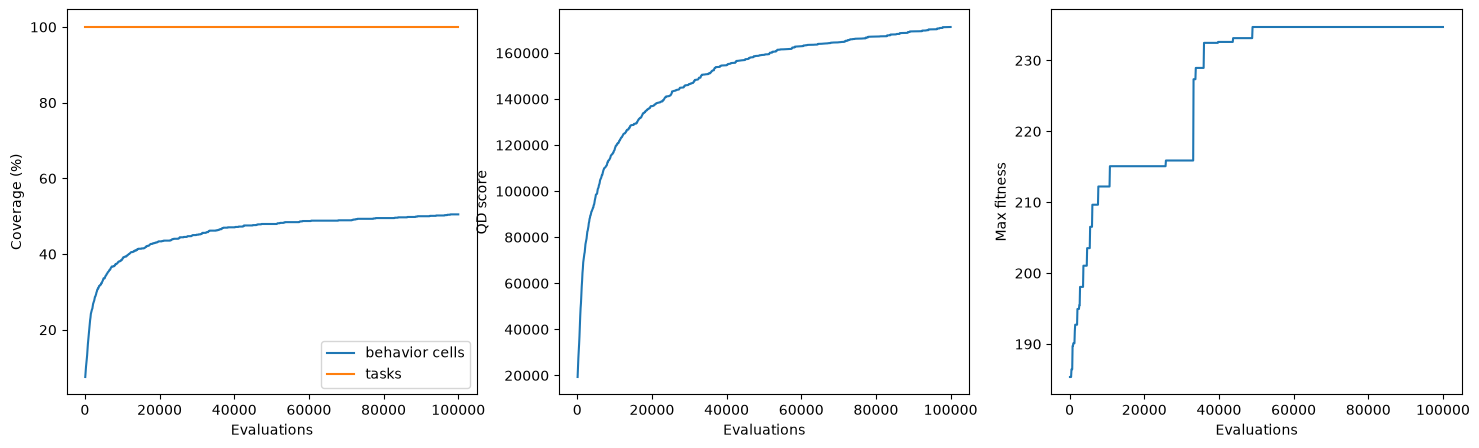

In [9]:
# create the x-axis array: each iteration evaluates batch_size offsprings
evaluations = jnp.arange(1, num_iterations + 1) * batch_size

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(evaluations, metrics["coverage"], label="behavior cells")
axes[0].plot(evaluations, metrics["task_coverage"], label="tasks")
axes[0].set_xlabel("Evaluations")
axes[0].set_ylabel("Coverage (%)")
axes[0].legend()
axes[1].plot(evaluations, metrics["qd_score"])
axes[1].set_xlabel("Evaluations")
axes[1].set_ylabel("QD score")
axes[2].plot(evaluations, metrics["max_fitness"])
axes[2].set_xlabel("Evaluations")
axes[2].set_ylabel("Max fitness")
plt.show()

## Plot the archives of a few tasks

Each task has its own MAP-Elites archive over the shared behavior space, which can be extracted with `get_task_repertoire` and visualised with the standard plotting tools. Below, the archives of the four corners of the task space: from the robot with both legs at minimal strength (left) to the undamaged robot (right), which corresponds to the environment optimized in the MAP-Elites notebook. All the maps share the same color scale.

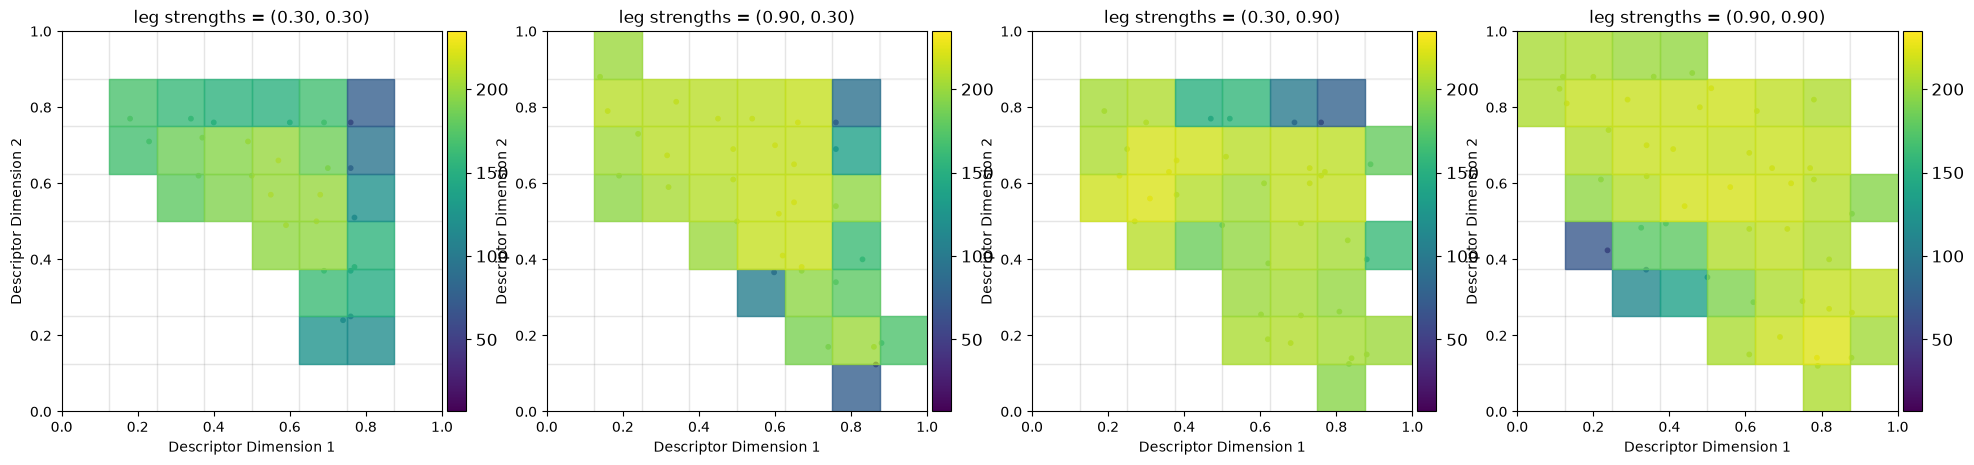

In [10]:
# shared color scale across the plotted tasks
occupied = repertoire.fitnesses[:, 0] != -jnp.inf
vmin = float(jnp.min(repertoire.fitnesses[occupied, 0]))
vmax = float(jnp.max(repertoire.fitnesses[occupied, 0]))

# the four corners of the task grid
corner_indices = [
    int(jnp.argmin(jnp.sum(task_descriptors, axis=1))),
    int(jnp.argmax(task_descriptors[:, 0] - task_descriptors[:, 1])),
    int(jnp.argmax(task_descriptors[:, 1] - task_descriptors[:, 0])),
    int(jnp.argmax(jnp.sum(task_descriptors, axis=1))),
]

fig, axes = plt.subplots(1, len(corner_indices), figsize=(24, 6))
for ax, task_index in zip(axes, corner_indices):
    task_repertoire = repertoire.get_task_repertoire(task_index)
    _, ax = plot_2d_map_elites_repertoire(
        centroids=task_repertoire.centroids,
        repertoire_fitnesses=task_repertoire.fitnesses,
        minval=0.0,
        maxval=1.0,
        repertoire_descriptors=task_repertoire.descriptors,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
    )
    strengths = task_descriptors[task_index]
    ax.set_title(
        f"leg strengths = ({float(strengths[0]):.2f}, {float(strengths[1]):.2f})"
    )
plt.show()